GRADIENT DESCENT - BATCH VS STOCHASTIC VS MINI BATCH

In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
df = pd.read_csv("social_network.csv")

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15121958,Male,58,121288,1
1,15671155,Female,36,98524,1
2,15131932,Female,29,27219,0
3,15365838,Female,26,15235,0
4,15259178,Female,24,57929,0
...,...,...,...,...,...
395,15912495,Male,41,61600,1
396,15657917,Male,55,91898,1
397,15824792,Female,52,45448,0
398,15737378,Female,47,41172,0


In [4]:
df = df[['Age','EstimatedSalary','Purchased']]

In [5]:
df

,Age,EstimatedSalary,Purchased
0,58,121288,1
1,36,98524,1
2,29,27219,0
3,26,15235,0
4,24,57929,0
...,...,...,...
395,41,61600,1
396,55,91898,1
397,52,45448,0
398,47,41172,0


In [6]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [7]:
X

,Age,EstimatedSalary
0,58,121288
1,36,98524
2,29,27219
3,26,15235
4,24,57929
...,...,...
395,41,61600
396,55,91898
397,52,45448
398,47,41172


In [8]:
y

0      1
1      1
2      0
3      0
4      0
      ..
395    1
396    1
397    0
398    0
399    0
Name: Purchased, Length: 400, dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled.shape

(400, 2)

In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()
model.add(Dense(10, activation='relu', input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\Meghali\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=500,batch_size=320,validation_split=0.2)
print(time.time() - start)       ##Batch

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5219 - loss: 0.6893 - val_accuracy: 0.3625 - val_loss: 0.7097
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5375 - loss: 0.6833 - val_accuracy: 0.3625 - val_loss: 0.7048
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5344 - loss: 0.6790 - val_accuracy: 0.3625 - val_loss: 0.7008
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5281 - loss: 0.6755 - val_accuracy: 0.3625 - val_loss: 0.6972
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5250 - loss: 0.6724 - val_accuracy: 0.3625 - val_loss: 0.6940
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5344 - loss: 0.6696 - val_accuracy: 0.3625 - val_loss: 0.6910
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5219 - loss: 0.6670 - val_accuracy: 0.3625 - val_loss: 0.6882
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5250 - loss: 0.6645 - val_accuracy: 0.3750 - val_

In [15]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history1 = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)
print(time.time() - start)          ##Stochastic

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0890 - val_accuracy: 0.9875 - val_loss: 0.0813
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9750 - loss: 0.0829 - val_accuracy: 0.9500 - val_loss: 0.0900
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 0.0777 - val_accuracy: 0.9500 - val_loss: 0.0897
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 0.0737 - val_accuracy: 0.9375 - val_loss: 0.0892
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 0.0711 - val_accuracy: 0.9875 - val_loss: 0.0674
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9750 - loss: 0.0695 - val_accuracy: 0.9875 - val_loss: 0.0679
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9844 - loss: 0.0647 - val_accuracy: 0.9875 - val_loss: 0.0650
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9844 - loss: 0.0616 - val_accu

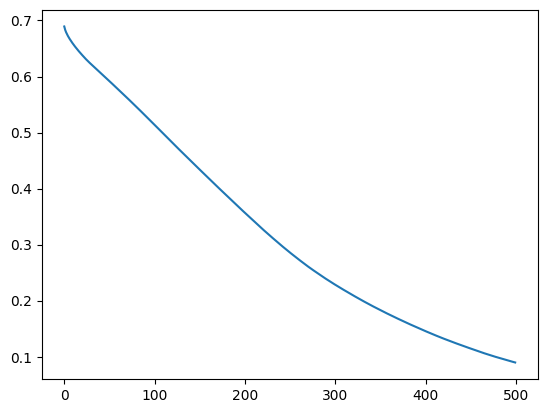

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

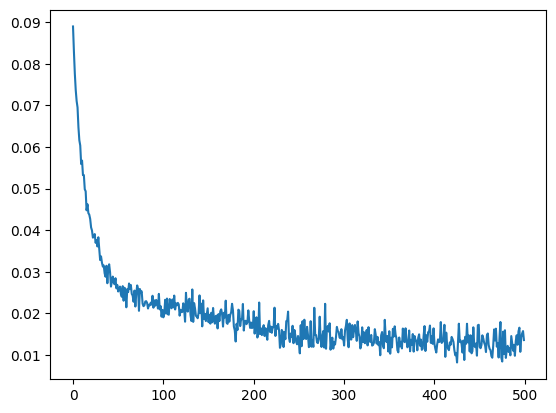

In [19]:
import matplotlib.pyplot as plt
plt.plot(history1.history['loss'])